# 🎗️ Breast Cancer Classification using SVM
### Support Vector Machine (SVM) - Beginner Friendly Notebook

**Dataset:** Breast Cancer Wisconsin Dataset (from Kaggle)  
**Goal:** Predict whether a tumor is **Malignant (M)** or **Benign (B)** using SVM

---
### 📌 What is SVM?
Support Vector Machine is a **supervised machine learning algorithm** that finds the best boundary (called a *hyperplane*) to separate two classes.
- Think of it as drawing a line between two groups of points
- SVM tries to **maximize the gap (margin)** between the two groups
- Works well for both linear and non-linear data

---

## Step 1: Import Required Libraries

In [1]:
# NumPy  - for numerical computations
import numpy as np

# Pandas - for loading and handling data (like Excel but in Python)
import pandas as pd

# Matplotlib & Seaborn - for creating plots and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - the main machine learning library
from sklearn.model_selection import train_test_split       # to split data into train and test
from sklearn.preprocessing import StandardScaler           # to normalize/scale features
from sklearn.svm import SVC                                # SVM Classifier
from sklearn.metrics import (
    classification_report,    # detailed performance report
    confusion_matrix,         # shows correct vs wrong predictions
    accuracy_score,           # overall accuracy
    roc_curve,                # ROC curve data
    auc                       # Area under ROC curve
)
from sklearn.decomposition import PCA                      # to reduce features for visualization
from sklearn.model_selection import cross_val_score        # for cross-validation

# To suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [3]:
# Load the CSV file into a DataFrame
# Make sure 'data.csv' is in the same folder as this notebook
df = pd.read_csv('data.csv')

# Show the first 5 rows to get a feel for the data
print(" First 5 rows of the dataset:")
df.head()

 First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Check the shape (rows, columns)
print(f" Dataset Shape: {df.shape}")
print(f"    Number of patients (rows): {df.shape[0]}")
print(f"    Number of features (columns): {df.shape[1]}")

 Dataset Shape: (569, 33)
    Number of patients (rows): 569
    Number of features (columns): 33


In [5]:
# Get basic statistics of the dataset
print("📊 Basic Statistics of the Dataset:")
df.describe()

📊 Basic Statistics of the Dataset:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
# Check for missing values (NaN values can cause errors in ML)
print("🔎 Checking for Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

# Check the data types of each column
print("\n📁 Column Data Types:")
print(df.dtypes)

🔎 Checking for Missing Values:
Unnamed: 32    569
dtype: int64

📁 Column Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoot

In [7]:
# Count how many Malignant (M) and Benign (B) cases we have
print(" Target Class Distribution:")
print(df['diagnosis'].value_counts())
print()
print("  M = Malignant (Cancerous) ")
print("  B = Benign (Non-Cancerous) ")

 Target Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

  M = Malignant (Cancerous) 
  B = Benign (Non-Cancerous) 


## Step 3: Data Visualization 📊
Always visualize data before training — it helps you understand patterns!

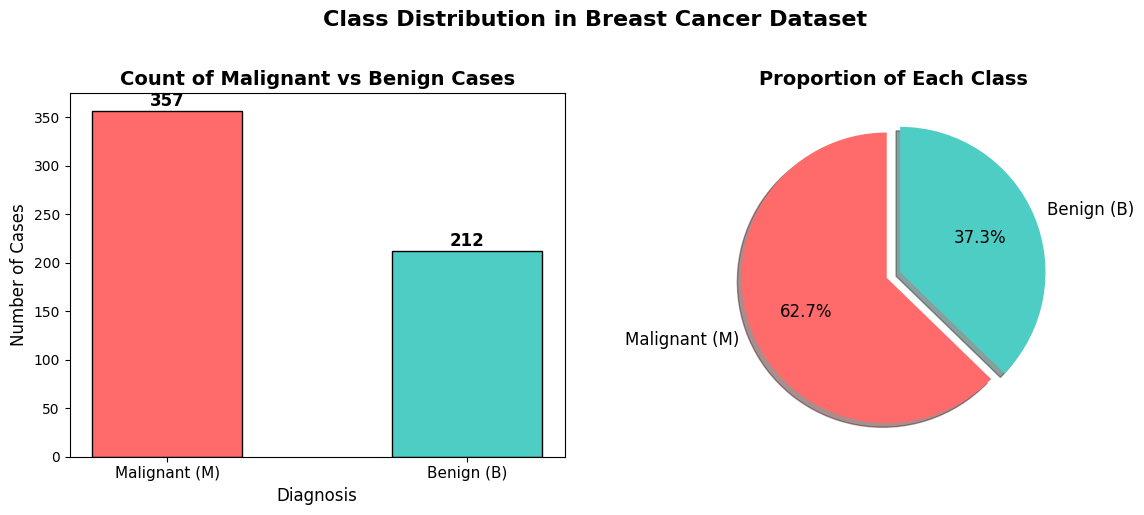

 This shows how balanced our dataset is between the two classes.


In [9]:
# --- Plot 1: Class Distribution (Bar + Pie Chart) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count of each class
class_counts = df['diagnosis'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']  # Red for Malignant, Teal for Benign

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Count of Malignant vs Benign Cases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Number of Cases', fontsize=12)
axes[0].set_xticklabels(['Malignant (M)', 'Benign (B)'], fontsize=11)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Malignant (M)', 'Benign (B)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0.05), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Proportion of Each Class', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution in Breast Cancer Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(" This shows how balanced our dataset is between the two classes.")

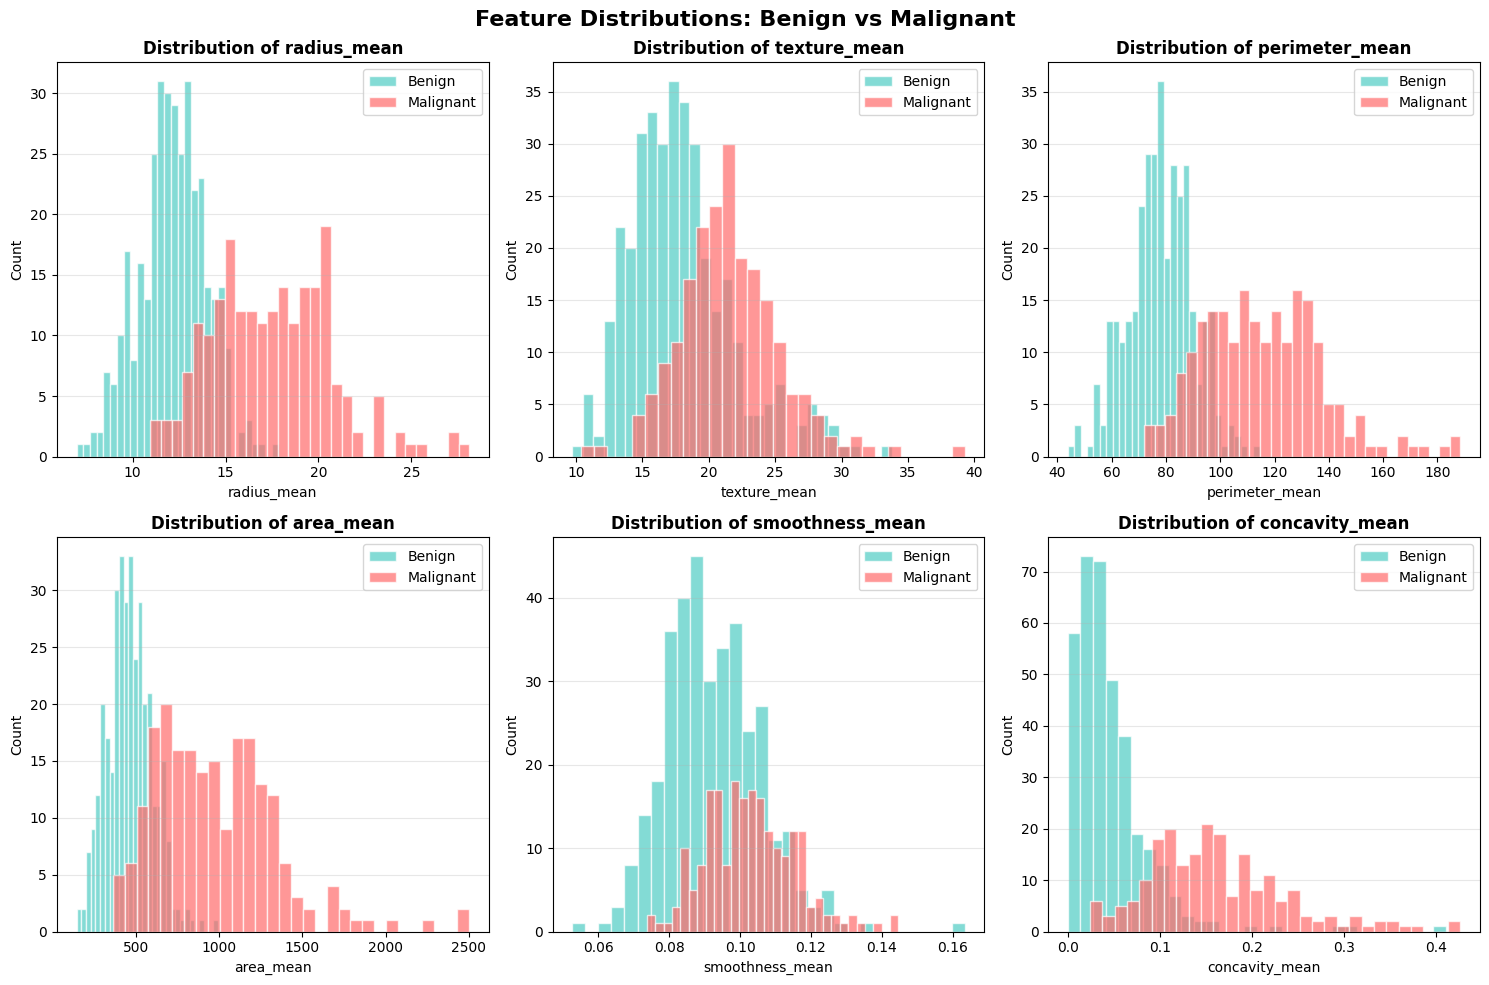

 Features where the two distributions DON'T overlap much are more useful for classification!


In [10]:
# --- Plot 2: Distribution of Key Features by Diagnosis ---
# We'll look at 6 important features
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                'area_mean', 'smoothness_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Make it a 1D list so we can loop easily

for i, feature in enumerate(key_features):
    # Plot histogram for Benign and Malignant separately
    axes[i].hist(df[df['diagnosis'] == 'B'][feature], bins=30,
                 alpha=0.7, color='#4ECDC4', label='Benign', edgecolor='white')
    axes[i].hist(df[df['diagnosis'] == 'M'][feature], bins=30,
                 alpha=0.7, color='#FF6B6B', label='Malignant', edgecolor='white')
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions: Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Features where the two distributions DON'T overlap much are more useful for classification!")

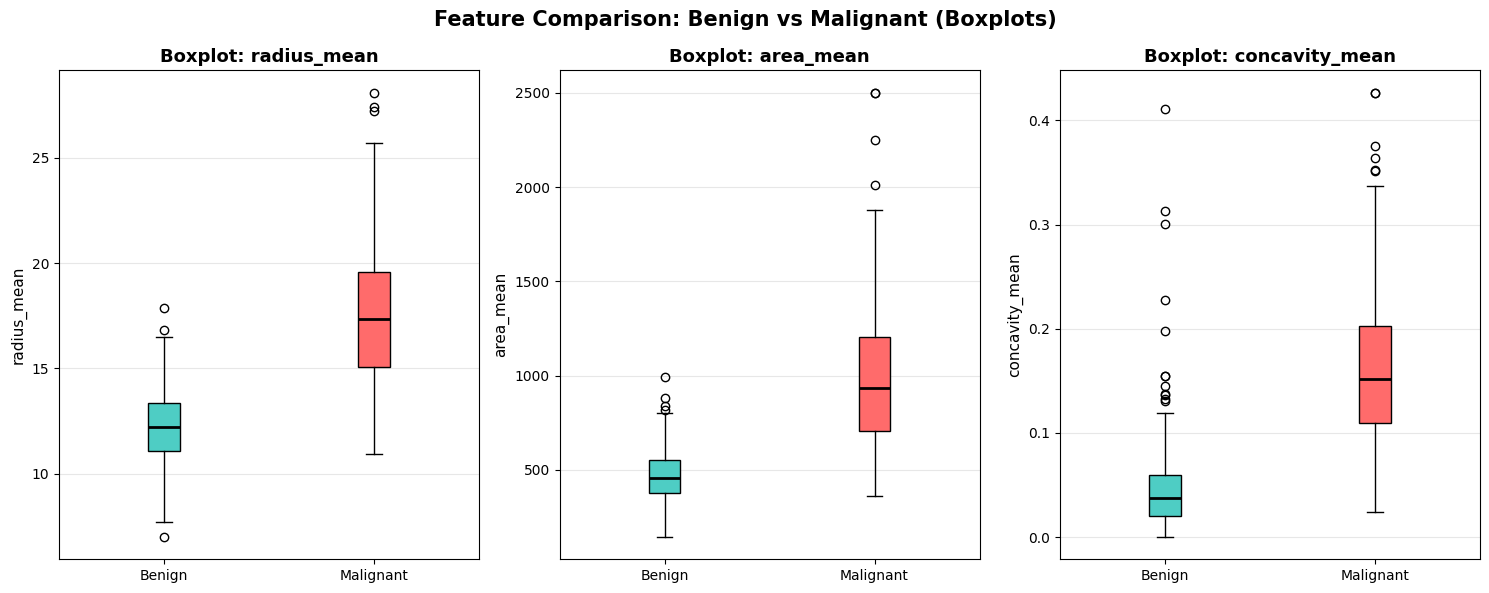

 Boxplots show the median (middle line) and spread of values.
   If boxes are far apart → the feature is very useful for separating the two classes!


In [12]:
# --- Plot 3: Boxplot to compare feature values by class ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

top_3 = ['radius_mean', 'area_mean', 'concavity_mean']

for i, feature in enumerate(top_3):
    # Boxplot shows median, spread, and outliers
    benign_data = df[df['diagnosis'] == 'B'][feature]
    malignant_data = df[df['diagnosis'] == 'M'][feature]

    bp = axes[i].boxplot([benign_data, malignant_data],
                          labels=['Benign', 'Malignant'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4ECDC4')
    bp['boxes'][1].set_facecolor('#FF6B6B')

    axes[i].set_title(f'Boxplot: {feature}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(feature, fontsize=11)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Comparison: Benign vs Malignant (Boxplots)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Boxplots show the median (middle line) and spread of values.")
print("   If boxes are far apart → the feature is very useful for separating the two classes!")

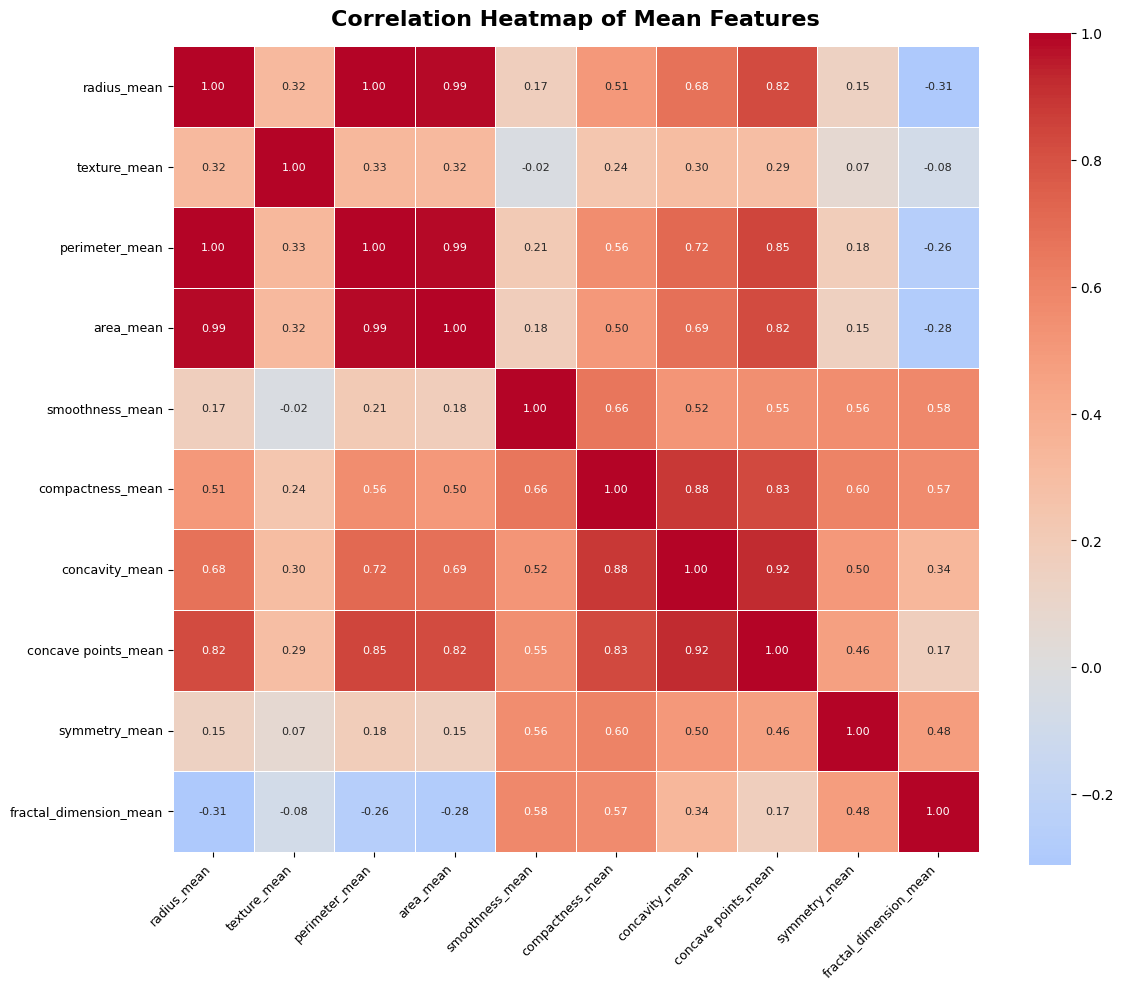

 Values close to 1 or -1 = strong correlation.
   Highly correlated features might be redundant — SVM handles this with scaling.


In [13]:
# --- Plot 4: Correlation Heatmap ---
# Heatmap shows how strongly features are related to each other

# Select only the '_mean' columns for simplicity
mean_cols = [col for col in df.columns if 'mean' in col]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show numbers in each cell
    fmt='.2f',            # 2 decimal places
    cmap='coolwarm',      # Color scheme
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap of Mean Features', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
print(" Values close to 1 or -1 = strong correlation.")
print("   Highly correlated features might be redundant — SVM handles this with scaling.")

## Step 4: Data Preprocessing 🛠️
Before training any ML model, we need to:
1. **Remove unnecessary columns** (like ID)
2. **Encode the target** (convert M/B to 1/0)
3. **Scale the features** (very important for SVM!)

In [14]:
# Step 4.1 - Remove the 'id' column (not useful for prediction)
# Also remove the last column if it's empty (some Kaggle datasets have trailing commas)
df = df.drop(columns=['id'], errors='ignore')

# Remove any unnamed/empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(" Removed unnecessary columns")
print(f"   Remaining columns: {df.shape[1]}")

 Removed unnecessary columns
   Remaining columns: 31


In [15]:
# Step 4.2 - Encode the target variable
# SVM needs numbers, not text labels
# M (Malignant) → 1
# B (Benign)    → 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(" Label Encoding Done!")
print("   M (Malignant) → 1")
print("   B (Benign)    → 0")
print(f"\n   New value counts:\n{df['diagnosis'].value_counts()}")

 Label Encoding Done!
   M (Malignant) → 1
   B (Benign)    → 0

   New value counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [16]:
# Step 4.3 - Separate features (X) and target label (y)
X = df.drop('diagnosis', axis=1)   # All columns except 'diagnosis'
y = df['diagnosis']                 # Only the 'diagnosis' column

print(f" Features (X) shape: {X.shape}  → {X.shape[0]} samples, {X.shape[1]} features")
print(f" Target  (y) shape: {y.shape}  → {y.shape[0]} labels")

 Features (X) shape: (569, 30)  → 569 samples, 30 features
 Target  (y) shape: (569,)  → 569 labels


In [17]:
# Step 4.4 - Split data into Training and Testing sets
# 80% data → Training (model learns from this)
# 20% data → Testing  (we evaluate model on unseen data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Fixed seed for reproducibility (same split every time)
    stratify=y           # Ensures equal class proportion in train and test
)

print(f" Data Split Complete!")
print(f"   Training set size : {X_train.shape[0]} samples")
print(f"   Testing  set size : {X_test.shape[0]} samples")

 Data Split Complete!
   Training set size : 455 samples
   Testing  set size : 114 samples


In [18]:
# Step 4.5 - Feature Scaling using StandardScaler
# WHY? SVM is sensitive to the scale of features.
# Example: 'area_mean' can be in 1000s, while 'smoothness_mean' is around 0.1
# Scaling brings all features to a similar range (mean=0, std=1)

scaler = StandardScaler()                      # Create the scaler object
X_train = scaler.fit_transform(X_train)        # Fit on training data and transform
X_test  = scaler.transform(X_test)             # Only transform test data (NO fitting!)

# NOTE: We NEVER fit the scaler on test data — that would cause 'data leakage'!

print(" Feature Scaling Done!")
print(f"   Training data mean (approx): {X_train.mean():.4f}  (should be close to 0)")
print(f"   Training data std  (approx): {X_train.std():.4f}  (should be close to 1)")

 Feature Scaling Done!
   Training data mean (approx): 0.0000  (should be close to 0)
   Training data std  (approx): 1.0000  (should be close to 1)


## Step 5: Train the SVM Model 🤖

We will train **4 different SVM kernels** and compare their accuracy:
- **Linear**: Draws a straight line/hyperplane to separate classes
- **RBF (Radial Basis Function)**: Most popular — good for non-linear data
- **Polynomial**: Uses polynomial curves to separate data
- **Sigmoid**: Similar to neural network activation

In [19]:
# Define the 4 kernels we want to try
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

# Dictionary to store results for each kernel
results = {}

print(" Training SVM with different kernels...\n")
print("-" * 45)

for kernel in kernels:
    # Create the SVM model with the current kernel
    # C=1 is the regularization parameter (higher C = less regularization)
    model = SVC(kernel=kernel, C=1, random_state=42, probability=True)

    # Train (fit) the model on training data
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    # Save the model and results
    results[kernel] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc
    }

    print(f"  Kernel: {kernel:10s} | Accuracy: {acc*100:.2f}%")

print("-" * 45)
best_kernel = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n Best Kernel: '{best_kernel}' with accuracy {results[best_kernel]['accuracy']*100:.2f}%")

 Training SVM with different kernels...

---------------------------------------------
  Kernel: linear     | Accuracy: 96.49%
  Kernel: rbf        | Accuracy: 97.37%
  Kernel: poly       | Accuracy: 88.60%
  Kernel: sigmoid    | Accuracy: 94.74%
---------------------------------------------

 Best Kernel: 'rbf' with accuracy 97.37%


## Step 6: Evaluate the Best Model 📈
We'll use the **RBF kernel** (generally best for this kind of data)

In [20]:
# Use the RBF kernel model for detailed evaluation
best_model = results['rbf']['model']
y_pred = results['rbf']['predictions']

print("=" * 50)
print("     MODEL EVALUATION REPORT (RBF Kernel SVM)")
print("=" * 50)

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"\n Accuracy : {acc * 100:.2f}%")
print("   (Out of every 100 patients, model correctly classifies this many)\n")

# Classification Report
print(" Classification Report:")
print("   (Precision, Recall, F1-Score for each class)\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

print(" Understanding the metrics:")
print("   Precision = Out of all predicted positives, how many were actually positive?")
print("   Recall    = Out of all actual positives, how many did we correctly identify?")
print("   F1-Score  = Balance between Precision and Recall (harmonic mean)")
print("   Support   = Number of actual samples in each class")

     MODEL EVALUATION REPORT (RBF Kernel SVM)

 Accuracy : 97.37%
   (Out of every 100 patients, model correctly classifies this many)

 Classification Report:
   (Precision, Recall, F1-Score for each class)

               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114

 Understanding the metrics:
   Precision = Out of all predicted positives, how many were actually positive?
   Recall    = Out of all actual positives, how many did we correctly identify?
   F1-Score  = Balance between Precision and Recall (harmonic mean)
   Support   = Number of actual samples in each class


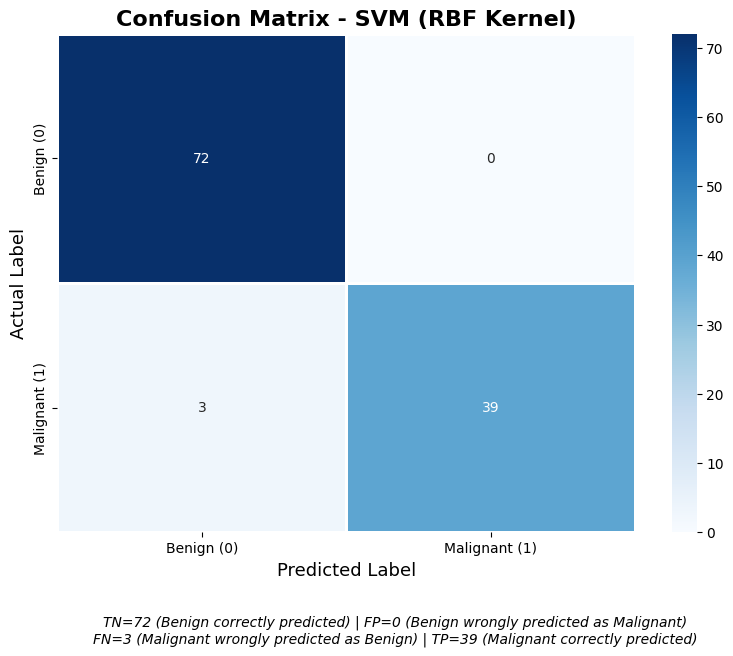


 Key Takeaway:
   In cancer detection, FALSE NEGATIVES (FN=3) are most dangerous!
   (Malignant tumor predicted as Benign — patient might not get treatment)


In [21]:
# --- Plot 5: Confusion Matrix ---
# Shows how many predictions were correct and where errors occurred

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,              # Show counts in each cell
    fmt='d',                 # Show as integers
    cmap='Blues',            # Blue color scheme
    xticklabels=['Benign (0)', 'Malignant (1)'],
    yticklabels=['Benign (0)', 'Malignant (1)'],
    linewidths=2,
    linecolor='white'
)
plt.title('Confusion Matrix - SVM (RBF Kernel)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)

# Add text explanation below
plt.figtext(0.5, -0.08,
    f"TN={cm[0,0]} (Benign correctly predicted) | FP={cm[0,1]} (Benign wrongly predicted as Malignant)\n"
    f"FN={cm[1,0]} (Malignant wrongly predicted as Benign) | TP={cm[1,1]} (Malignant correctly predicted)",
    ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

print("\n Key Takeaway:")
print(f"   In cancer detection, FALSE NEGATIVES (FN={cm[1,0]}) are most dangerous!")
print("   (Malignant tumor predicted as Benign — patient might not get treatment)")

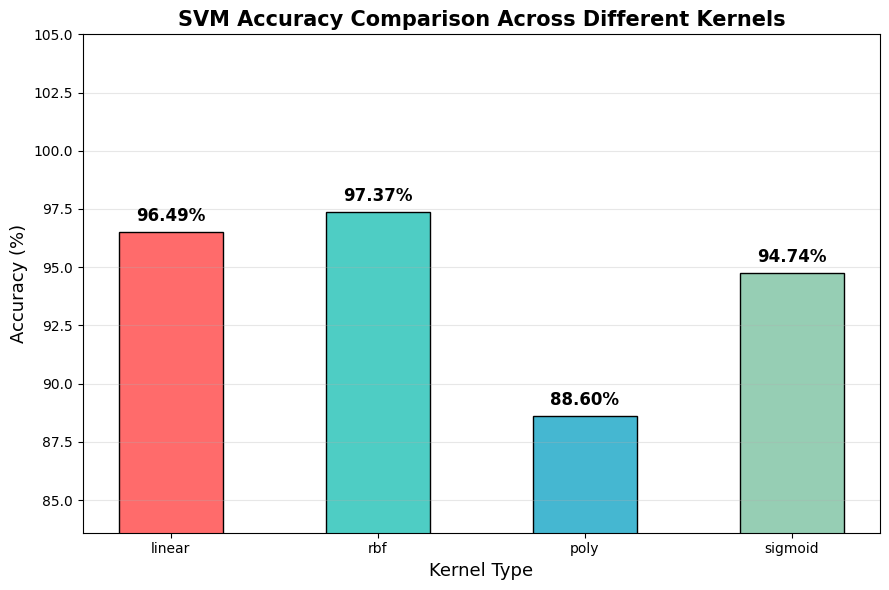

In [22]:
# --- Plot 6: Kernel Accuracy Comparison ---

kernel_names = list(results.keys())
accuracies = [results[k]['accuracy'] * 100 for k in kernel_names]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(9, 6))
bars = plt.bar(kernel_names, accuracies, color=colors_bar, edgecolor='black', width=0.5)

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('SVM Accuracy Comparison Across Different Kernels', fontsize=15, fontweight='bold')
plt.xlabel('Kernel Type', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim([min(accuracies) - 5, 105])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: ROC Curve 📉
ROC (Receiver Operating Characteristic) curve shows how well the model distinguishes between the two classes.

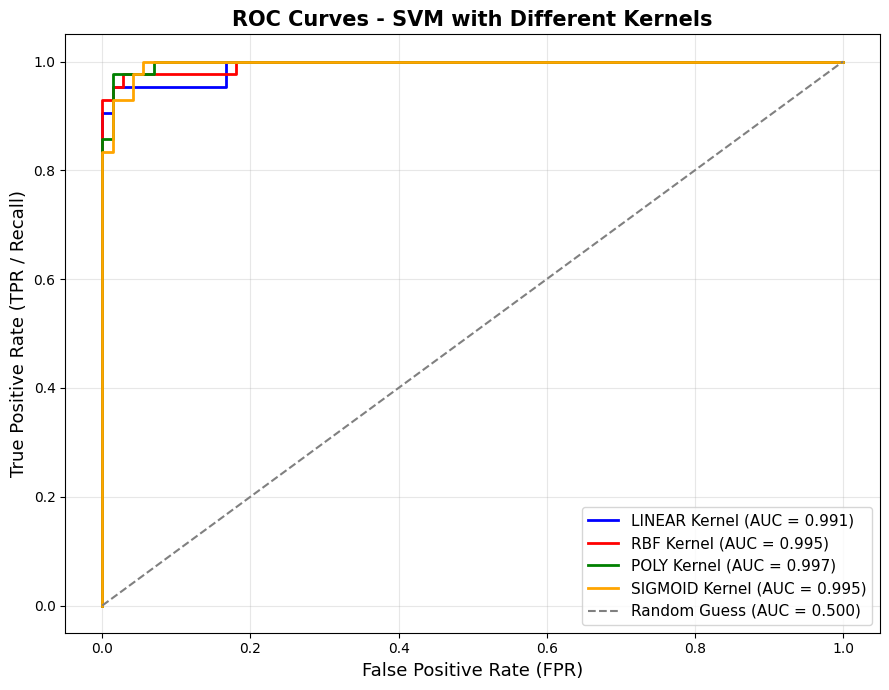

 AUC Score Interpretation:
   AUC = 1.0 → Perfect model
   AUC = 0.5 → Random guessing (useless model)
   AUC > 0.9 → Excellent!


In [24]:
# --- Plot 7: ROC Curves for all kernels ---

plt.figure(figsize=(9, 7))

for kernel, color in zip(kernels, ['blue', 'red', 'green', 'orange']):
    model = results[kernel]['model']

    # Get probability of being Malignant (class=1)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate False Positive Rate, True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC = Area under the curve (closer to 1 = better)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{kernel.upper()} Kernel (AUC = {roc_auc:.3f})')

# Diagonal line = random guessing (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.500)')

plt.title('ROC Curves - SVM with Different Kernels', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=13)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(" AUC Score Interpretation:")
print("   AUC = 1.0 → Perfect model")
print("   AUC = 0.5 → Random guessing (useless model)")
print("   AUC > 0.9 → Excellent!")

## Step 8: Visualize Decision Boundary using PCA 🗺️
SVM has 30 features — we can't visualize 30 dimensions!
So we use **PCA** to reduce to 2D and then plot the decision boundary.

In [25]:
# --- PCA: Reduce 30 features → 2 features for visualization ---
# PCA = Principal Component Analysis
# It finds the 2 most important 'directions' in the data

pca = PCA(n_components=2)                      # Keep only 2 components
X_train_pca = pca.fit_transform(X_train)       # Fit and transform training data
X_test_pca  = pca.transform(X_test)            # Transform test data

explained = pca.explained_variance_ratio_ * 100
print(f" PCA Done!")
print(f"   Component 1 explains: {explained[0]:.2f}% of variance")
print(f"   Component 2 explains: {explained[1]:.2f}% of variance")
print(f"   Total variance kept : {sum(explained):.2f}%")

# Train a new SVM on the 2D PCA data (for visualization only)
svm_pca = SVC(kernel='rbf', C=1, random_state=42)
svm_pca.fit(X_train_pca, y_train)
print("\n SVM trained on PCA-reduced data!")

 PCA Done!
   Component 1 explains: 44.59% of variance
   Component 2 explains: 18.55% of variance
   Total variance kept : 63.14%

 SVM trained on PCA-reduced data!


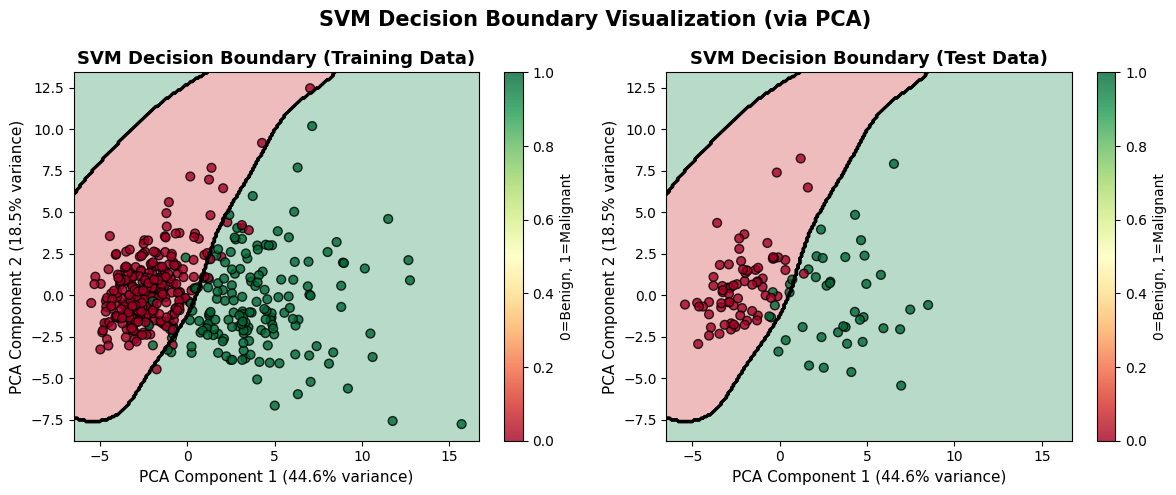

 The black line = SVM Decision Boundary
   Green region → Benign, Red region → Malignant
   Points in the wrong region are misclassifications.


In [26]:
# --- Plot 8: SVM Decision Boundary (2D using PCA) ---

# Create a mesh grid to draw decision regions
h = 0.1  # Step size (smaller = smoother boundary but slower)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# Predict class for each point in the mesh
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 5))

# ----- Training Data Decision Boundary -----
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')  # Background regions
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)  # Decision boundary line

# Plot the actual data points
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='RdYlGn', edgecolors='black',
                      s=40, alpha=0.8)
plt.title('SVM Decision Boundary (Training Data)', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PCA Component 2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.colorbar(scatter, label='0=Benign, 1=Malignant')

# ----- Test Data Decision Boundary -----
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)

scatter2 = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                       c=y_test, cmap='RdYlGn', edgecolors='black',
                       s=40, alpha=0.8)
plt.title('SVM Decision Boundary (Test Data)', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PCA Component 2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.colorbar(scatter2, label='0=Benign, 1=Malignant')

plt.suptitle('SVM Decision Boundary Visualization (via PCA)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(" The black line = SVM Decision Boundary")
print("   Green region → Benign, Red region → Malignant")
print("   Points in the wrong region are misclassifications.")

## Step 9: Cross-Validation 🔄
Cross-validation gives a more reliable estimate of model performance by testing on different parts of the data.

In [27]:
# --- 5-Fold Cross Validation ---
# The data is split into 5 parts. Model is trained on 4 parts and tested on 1.
# This is repeated 5 times (each part acts as test set once).

print(" Performing 5-Fold Cross-Validation on RBF SVM...\n")

# Combine train and test back for cross-validation on full dataset
X_all = np.vstack([X_train, X_test])  # Stack back together
y_all = pd.concat([y_train, y_test]).values

svm_cv = SVC(kernel='rbf', C=1, random_state=42)
cv_scores = cross_val_score(svm_cv, X_all, y_all, cv=5, scoring='accuracy')

print(f"  Cross-Validation Scores for each fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"    Fold {i}: {score * 100:.2f}%")

print(f"\n   Mean CV Accuracy : {cv_scores.mean() * 100:.2f}%")
print(f"   Std  CV Accuracy : ±{cv_scores.std() * 100:.2f}%")
print("\n  Low standard deviation = Consistent model performance!")

 Performing 5-Fold Cross-Validation on RBF SVM...

  Cross-Validation Scores for each fold:
    Fold 1: 98.25%
    Fold 2: 98.25%
    Fold 3: 97.37%
    Fold 4: 96.49%
    Fold 5: 97.35%

   Mean CV Accuracy : 97.54%
   Std  CV Accuracy : ±0.66%

  Low standard deviation = Consistent model performance!


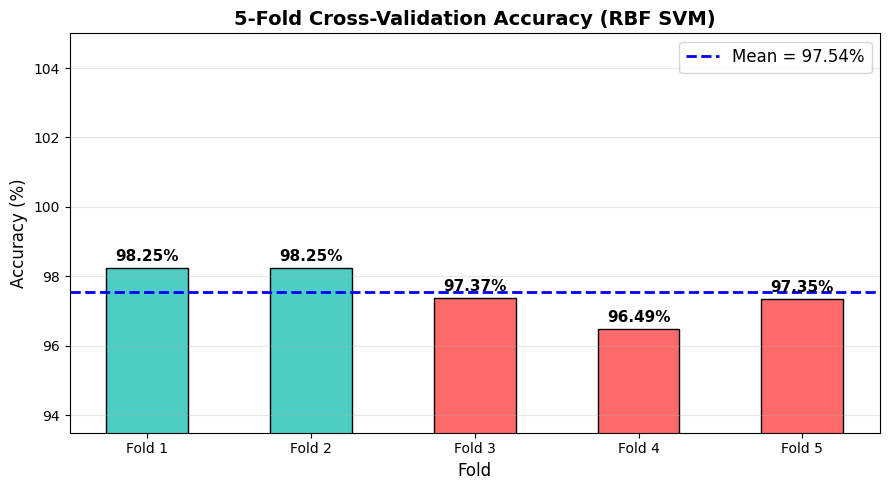

In [28]:
# --- Plot 9: Cross-Validation Score Visualization ---
plt.figure(figsize=(9, 5))

folds = [f'Fold {i}' for i in range(1, 6)]
colors_cv = ['#4ECDC4' if s >= cv_scores.mean() else '#FF6B6B' for s in cv_scores]

bars = plt.bar(folds, cv_scores * 100, color=colors_cv, edgecolor='black', width=0.5)

# Draw a horizontal line for the mean accuracy
plt.axhline(y=cv_scores.mean() * 100, color='blue', linestyle='--',
            linewidth=2, label=f'Mean = {cv_scores.mean()*100:.2f}%')

# Add labels on bars
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{score*100:.2f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.title('5-Fold Cross-Validation Accuracy (RBF SVM)', fontsize=14, fontweight='bold')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim([min(cv_scores * 100) - 3, 105])
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10: Final Summary 📝

In [29]:
# --- Final Summary ---
print("=" * 60)
print("          🎗️ BREAST CANCER SVM CLASSIFICATION SUMMARY")
print("=" * 60)
print(f"\n Dataset       : Breast Cancer Wisconsin (Kaggle)")
print(f" Total Samples : {df.shape[0]} patients")
print(f" Features Used : {X.shape[1]} cell nucleus measurements")
print(f"Classes       : Benign (0) | Malignant (1)")

print(f"\n Preprocessing:")
print(f"    Removed ID column")
print(f"   Label encoded (M→1, B→0)")
print(f"    StandardScaler applied")
print(f"    80-20 Train-Test Split")

print(f"\n SVM Kernel Results:")
for k, res in results.items():
    marker = " " if k == best_kernel else ""
    print(f"   {k:10s}: {res['accuracy']*100:.2f}%{marker}")

print(f"\n Cross-Validation (RBF, 5-Fold):")
print(f"   Mean Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"   Std Deviation : ±{cv_scores.std()*100:.2f}%")

print(f"\nKey Learnings:")
print(f"   1. SVM finds the best hyperplane to separate classes")
print(f"   2. RBF kernel generally works best for complex data")
print(f"   3. Feature scaling is CRITICAL for SVM")
print(f"   4. Cross-validation gives reliable accuracy estimates")
print(f"   5. In medical ML, Recall matters more than Accuracy!")
print("=" * 60)

          🎗️ BREAST CANCER SVM CLASSIFICATION SUMMARY

 Dataset       : Breast Cancer Wisconsin (Kaggle)
 Total Samples : 569 patients
 Features Used : 30 cell nucleus measurements
Classes       : Benign (0) | Malignant (1)

 Preprocessing:
    Removed ID column
   Label encoded (M→1, B→0)
    StandardScaler applied
    80-20 Train-Test Split

 SVM Kernel Results:
   linear    : 96.49%
   rbf       : 97.37% 
   poly      : 88.60%
   sigmoid   : 94.74%

 Cross-Validation (RBF, 5-Fold):
   Mean Accuracy : 97.54%
   Std Deviation : ±0.66%

Key Learnings:
   1. SVM finds the best hyperplane to separate classes
   2. RBF kernel generally works best for complex data
   3. Feature scaling is CRITICAL for SVM
   4. Cross-validation gives reliable accuracy estimates
   5. In medical ML, Recall matters more than Accuracy!
